In [4]:
from pathlib import Path
import pandas as pd

# 1. Define your local Windows folder path
data_dir = Path(r"C:\Users\Darrie\Desktop\BIGDATA\data\raw")

# 2. Grab and sort the CSV files from that folder
csv_files = sorted(data_dir.glob("*.csv"))

if len(csv_files) == 0:
    print(f"❌ No CSV files found in: {data_dir}")
else:
    print(f"Found {len(csv_files)} files. Combining them now...")

    # 3. Read and combine all CSV files
    combined_df = pd.concat(
        [pd.read_csv(file) for file in csv_files], ignore_index=True
    )

    # 4. FIXED: Save the file to your actual Desktop folder
    output_path = data_dir / "metraq_aq_combined_2001_2024.csv"
    combined_df.to_csv(output_path, index=False)

    print(f"✅ Files combined successfully!")
    print(f"📁 Saved to: {output_path}")
    print(f"📊 Combined dataset shape: {combined_df.shape}")

Found 24 files. Combining them now...
✅ Files combined successfully!
📁 Saved to: C:\Users\Darrie\Desktop\BIGDATA\data\raw\metraq_aq_combined_2001_2024.csv
📊 Combined dataset shape: (64881744, 9)


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import pyspark
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import PCA, StandardScaler, VectorAssembler
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col

# 1. Initialize Spark Session optimized for your local machine
spark = (
    SparkSession.builder.appName("AirQualityKMeans")
    .config(
        "spark.driver.memory", "8g"
    )  # Gives Spark more RAM to process your 65M rows
    .master("local[*]")  # Uses all available CPU cores on your laptop
    .getOrCreate()
)

# 2. FIXED: Update path to your local Windows folder
# Note the 'file:///' prefix and forward slashes, which PySpark prefers on Windows
file_path = "file:///C:/Users/Darrie/Desktop/BIGDATA/data/raw/metraq_aq_combined_2001_2024.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)

# 3. View the structure and first few rows
df.printSchema()
df.show(5)

root
 |-- sensor_id: integer (nullable = true)
 |-- sensor_name: string (nullable = true)
 |-- utm_x: double (nullable = true)
 |-- utm_y: double (nullable = true)
 |-- magnitude_id: integer (nullable = true)
 |-- magnitude_name: string (nullable = true)
 |-- entry_date: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- is_interpolated: integer (nullable = true)

+---------+---------------+-----------+-----------+------------+--------------+-------------------+-----+---------------+
|sensor_id|    sensor_name|      utm_x|      utm_y|magnitude_id|magnitude_name|         entry_date|value|is_interpolated|
+---------+---------------+-----------+-----------+------------+--------------+-------------------+-----+---------------+
| 28079004|Plaza de España|439579.3291|4475049.263|           1|           SO2|2001-01-01 00:00:00| 21.0|              0|
| 28079004|Plaza de España|439579.3291|4475049.263|           6|            CO|2001-01-01 00:00:00|  1.0|              0|
| 28

In [6]:
# Clean and prepare data
df_clean = df.select(
    "sensor_id",
    "sensor_name",
    "entry_date",
    "magnitude_name",
    "value"
).dropna()

df_clean = df_clean.withColumn("value", col("value").cast("double"))

# Pivot pollutants into columns
pivot_df = df_clean.groupBy(
    "sensor_id",
    "sensor_name",
    "entry_date"
).pivot("magnitude_name").agg(avg("value"))

pivot_df.show(5)


+---------+---------------+-------------------+-----+------+-------+---+----+-----------+-----------------------+------------------+----+------+-----+----+------+----+------+----------+---------------+-------------+-------------------+----+-------------+----+----+------+----------+---------------+-------------+-------------------+----+------+----------+---------------+-------------+-------------------+-------+----+
|sensor_id|    sensor_name|         entry_date|<PM10|<PM2.5|BENCENO| CO|  DV|ETILBENCENO|HIDROCARBS_NO_METANICOS|HIDROCARBS_TOTALES|  HR|METANO|   NO| NO2|   NOX|  O3|OC_IDW|OC_KRIGING|OC_RBF_GAUSSIAN|OC_RBF_LINEAR|OC_RBF_MULTIQUADRIQ| PRE|PRECIPITACION|  RS| SO2|SP_IDW|SP_KRIGING|SP_RBF_GAUSSIAN|SP_RBF_LINEAR|SP_RBF_MULTIQUADRIQ|TEMP|TI_IDW|TI_KRIGING|TI_RBF_GAUSSIAN|TI_RBF_LINEAR|TI_RBF_MULTICUADRIC|TOLUENO|  VV|
+---------+---------------+-------------------+-----+------+-------+---+----+-----------+-----------------------+------------------+----+------+-----+----+------+

In [7]:
# Fill missing values
pivot_df = pivot_df.na.fill(0)

# Select numeric feature columns
feature_cols = [
    c for c, t in pivot_df.dtypes
    if t in ["int", "bigint", "double", "float"] and c != "sensor_id"
]

print(feature_cols)

['<PM10', '<PM2.5', 'BENCENO', 'CO', 'DV', 'ETILBENCENO', 'HIDROCARBS_NO_METANICOS', 'HIDROCARBS_TOTALES', 'HR', 'METANO', 'NO', 'NO2', 'NOX', 'O3', 'OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'PRE', 'PRECIPITACION', 'RS', 'SO2', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TEMP', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC', 'TOLUENO', 'VV']


In [8]:
from pyspark.sql.functions import col
import re

# Rename columns to safe names
def clean_col_name(name):
    return re.sub(r"[^a-zA-Z0-9_]", "_", name)

for old_name in pivot_df.columns:
    new_name = clean_col_name(old_name)
    pivot_df = pivot_df.withColumnRenamed(old_name, new_name)

pivot_df.printSchema()

root
 |-- sensor_id: integer (nullable = true)
 |-- sensor_name: string (nullable = true)
 |-- entry_date: timestamp (nullable = true)
 |-- _PM10: double (nullable = false)
 |-- _PM2_5: double (nullable = false)
 |-- BENCENO: double (nullable = false)
 |-- CO: double (nullable = false)
 |-- DV: double (nullable = false)
 |-- ETILBENCENO: double (nullable = false)
 |-- HIDROCARBS_NO_METANICOS: double (nullable = false)
 |-- HIDROCARBS_TOTALES: double (nullable = false)
 |-- HR: double (nullable = false)
 |-- METANO: double (nullable = false)
 |-- NO: double (nullable = false)
 |-- NO2: double (nullable = false)
 |-- NOX: double (nullable = false)
 |-- O3: double (nullable = false)
 |-- OC_IDW: double (nullable = false)
 |-- OC_KRIGING: double (nullable = false)
 |-- OC_RBF_GAUSSIAN: double (nullable = false)
 |-- OC_RBF_LINEAR: double (nullable = false)
 |-- OC_RBF_MULTIQUADRIQ: double (nullable = false)
 |-- PRE: double (nullable = false)
 |-- PRECIPITACION: double (nullable = false)
 

In [9]:
# Select numeric feature columns again after renaming
feature_cols = [
    c for c, t in pivot_df.dtypes
    if t in ["int", "bigint", "double", "float"] and c != "sensor_id"
]

print(feature_cols)

['_PM10', '_PM2_5', 'BENCENO', 'CO', 'DV', 'ETILBENCENO', 'HIDROCARBS_NO_METANICOS', 'HIDROCARBS_TOTALES', 'HR', 'METANO', 'NO', 'NO2', 'NOX', 'O3', 'OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'PRE', 'PRECIPITACION', 'RS', 'SO2', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TEMP', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC', 'TOLUENO', 'VV']


In [10]:
# Assemble features
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

assembled_df = assembler.transform(pivot_df)

# Scale features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

In [11]:
# Faster Sensitivity Analysis using sample

sampled_df = scaled_df.sample(
    fraction=0.05,
    seed=42
).cache()

print("Sample count:", sampled_df.count())

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

results = []

for k in range(2, 7):
    kmeans = KMeans(
        featuresCol="features",
        predictionCol="prediction",
        k=k,
        seed=42,
        maxIter=5
    )

    model = kmeans.fit(sampled_df)
    predictions = model.transform(sampled_df)

    silhouette = evaluator.evaluate(predictions)
    inertia = model.summary.trainingCost

    results.append((k, inertia, silhouette))

results_df = pd.DataFrame(
    results,
    columns=["k", "inertia", "silhouette_score"]
)

display(results_df)

Sample count: 206242


,k,inertia,silhouette_score
0,2,6.468069e+06,0.356269
1,3,5.994844e+06,0.346772
2,4,5.561871e+06,0.360060
3,5,5.423649e+06,0.321293
4,6,4.951767e+06,0.305151


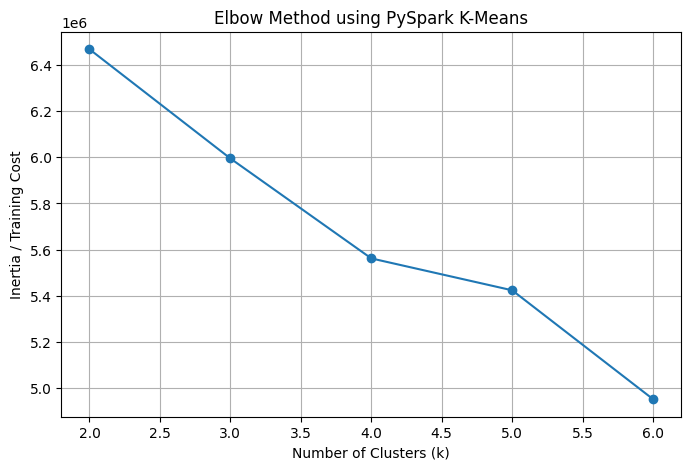

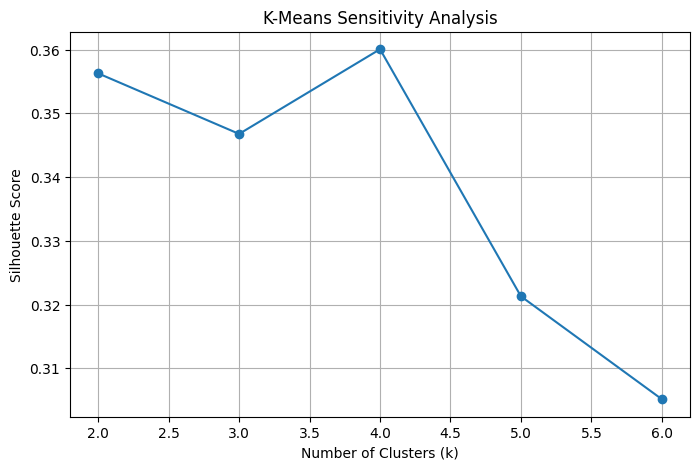

In [12]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / Training Cost")
plt.title("Elbow Method using PySpark K-Means")
plt.grid(True)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Sensitivity Analysis")
plt.grid(True)
plt.show()

In [13]:
# Choose best k
best_k = int(results_df.loc[results_df["silhouette_score"].idxmax(), "k"])
print("Best k:", best_k)

Best k: 4


In [14]:
# Final K-Means Model
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=best_k,
    seed=42
)

kmeans_model = kmeans.fit(scaled_df)
clustered_df = kmeans_model.transform(scaled_df)

clustered_df.select(
    "sensor_id",
    "sensor_name",
    "entry_date",
    "cluster"
).show(10)

+---------+---------------+-------------------+-------+
|sensor_id|    sensor_name|         entry_date|cluster|
+---------+---------------+-------------------+-------+
| 28079004|Plaza de España|2001-01-29 04:00:00|      0|
| 28079004|Plaza de España|2001-02-10 23:00:00|      3|
| 28079004|Plaza de España|2001-04-06 16:00:00|      0|
| 28079004|Plaza de España|2001-05-09 01:00:00|      0|
| 28079004|Plaza de España|2001-06-11 00:00:00|      0|
| 28079004|Plaza de España|2001-06-28 22:00:00|      3|
| 28079004|Plaza de España|2001-08-28 06:00:00|      0|
| 28079004|Plaza de España|2001-10-11 19:00:00|      0|
| 28079004|Plaza de España|2001-10-28 15:00:00|      0|
| 28079004|Plaza de España|2001-10-31 01:00:00|      3|
+---------+---------------+-------------------+-------+
only showing top 10 rows


In [15]:
import numpy as np
import pandas as pd
from pyspark.ml.feature import PCA

# =====================================================================
# SAFE-GUARD: In case 'clustered_df' wasn't assigned in a previous cell,
# uncomment the line below to point it to your active ML dataframe:
# clustered_df = final_kmeans_output_df
# =====================================================================

# 1. Initialize and run PCA for visualization
pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca_features"
)

pca_model = pca.fit(clustered_df)
pca_df = pca_model.transform(clustered_df)

# 2. Convert a small 5% sample to Pandas for local plotting
plot_df = pca_df.select("pca_features", "cluster").sample(
    fraction=0.05,
    seed=42
).toPandas()

# 3. FIX: Safely parse the Spark DenseVector items into distinct columns
# We use .values[0] and .values[1] to bypass PySpark-to-Pandas object mapping errors.
plot_df["PC1"] = plot_df["pca_features"].apply(lambda x: float(x.values[0]) if hasattr(x, "values") else float(x[0]))
plot_df["PC2"] = plot_df["pca_features"].apply(lambda x: float(x.values[1]) if hasattr(x, "values") else float(x[1]))

# Clean up the vector column since you have PC1 and PC2 now
plot_df = plot_df.drop(columns=["pca_features"])

print("Success! Your plotting DataFrame is ready:")
print(plot_df.head())

Success! Your plotting DataFrame is ready:
   cluster       PC1       PC2
0        3 -3.036809 -3.066788
1        0 -2.176920  0.721801
2        3 -3.362677 -4.531212
3        0 -2.227431  0.365642
4        0 -2.229425  0.362128


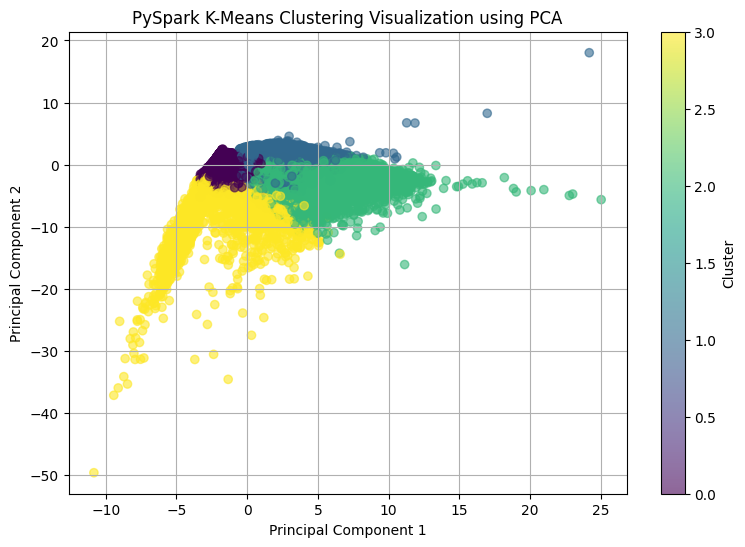

In [16]:
# K-Means Visualization
plt.figure(figsize=(9, 6))
plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster"],
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PySpark K-Means Clustering Visualization using PCA")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [17]:
# Cluster Summary
cluster_summary = clustered_df.groupBy("cluster").agg(
    *[avg(c).alias(f"avg_{c}") for c in feature_cols]
)

cluster_summary.show()

+-------+------------------+------------------+--------------------+--------------------+-------------------+-------------------+---------------------------+----------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+-------------------+------------------+--------------------+------------------+-----------------------+------------------+--------------------+--------------------+------------------+------------------+------------------+--------------------+------------------+-----------------------+--------------------+------------------+------------------+--------------------+------------------+-----------------------+-------------------+--------------------+
|cluster|         avg__PM10|        avg__PM2_5|         avg_BENCENO|              avg_CO|             avg_DV|    avg_ETILBENCENO|avg_HIDROCARBS_NO_METANICOS|avg_HIDROCARBS_TOTALES|              avg_HR|         avg_METANO|            avg_NO|           av

In [18]:
# Cluster Stability Analysis
base_model = KMeans(
    featuresCol="features",
    predictionCol="base_cluster",
    k=best_k,
    seed=42
).fit(scaled_df)

base_predictions = base_model.transform(scaled_df).select(
    "sensor_id",
    "entry_date",
    "base_cluster"
)

stability_results = []

for seed in [0, 10, 20, 30, 40, 50]:
    temp_model = KMeans(
        featuresCol="features",
        predictionCol="temp_cluster",
        k=best_k,
        seed=seed
    ).fit(scaled_df)

    temp_predictions = temp_model.transform(scaled_df).select(
        "sensor_id",
        "entry_date",
        "temp_cluster"
    )

    joined = base_predictions.join(
        temp_predictions,
        on=["sensor_id", "entry_date"],
        how="inner"
    )

    agreement = joined.filter(
        col("base_cluster") == col("temp_cluster")
    ).count() / joined.count()

    stability_results.append((seed, agreement))

stability_df = pd.DataFrame(
    stability_results,
    columns=["random_seed", "cluster_agreement"]
)

display(stability_df)

,random_seed,cluster_agreement
0,0,0.208999
1,10,0.757638
2,20,0.721175
3,30,0.999984
4,40,0.536605
5,50,0.081214


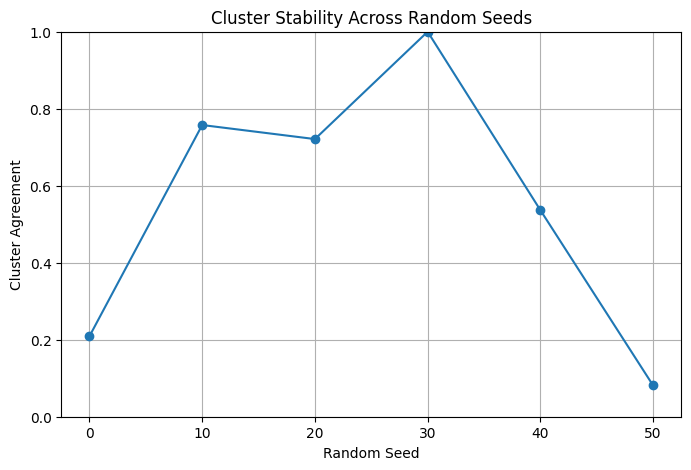

In [19]:
# Plot Cluster Stability
plt.figure(figsize=(8, 5))
plt.plot(
    stability_df["random_seed"],
    stability_df["cluster_agreement"],
    marker="o"
)
plt.xlabel("Random Seed")
plt.ylabel("Cluster Agreement")
plt.title("Cluster Stability Across Random Seeds")
plt.ylim(0, 1)
plt.grid(True)
plt.show()